In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# path = 'P:\\Lukas_Gehrke\\NAH\\behavior\\5_single-subject-EEG-analysis'
path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'

df = pd.read_csv(path + fname, delimiter=';')

# print unique values of the column 'id'
print(df['id'].unique())
# and count
print(len(df['id'].unique()))

[ 7  9 10 11 12 14 15 16 17 18 19 20 21 22]
14


### Data Cleaning

In [11]:

# # data cleaning
# # df = df[df.bad_epoch != 1]

# # remove outliers for each level of hapticProfile
# # df = df.groupby('hapticProfile').transform(lambda x: x[(x - x.mean()).abs() <= 2 * x.std()])

# # select only the first 5 trials of each hapticProfile
# # df = df.groupby(['hapticProfile', 'id']).head(10)

# # Assuming df is your DataFrame
# def remove_outliers_tukey(df, column):
    
#     tmp_df = df[df['hapticProfile'] == column]
#     Q1 = tmp_df['answerID'].quantile(0.25)
#     Q3 = tmp_df['answerID'].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - .25 * IQR
#     upper_bound = Q3 + .25 * IQR
#     return tmp_df[(tmp_df['answerID'] >= lower_bound) & (tmp_df['answerID'] <= upper_bound)]

# df_base = remove_outliers_tukey(df, 'baseline')
# df_sound = remove_outliers_tukey(df, 'sound')
# df_vibration = remove_outliers_tukey(df, 'vibration')
# df_vibration_sound = remove_outliers_tukey(df, 'vibration+sound')

# df = pd.concat([df_base, df_sound, df_vibration, df_vibration_sound])


## Answer ID results

### Plot hapticProfile x answerID

                     mean       std
hapticProfile                      
baseline         0.449932  0.226991
sound            0.436406  0.231852
vibration        0.554540  0.230452
vibration+sound  0.510703  0.233063


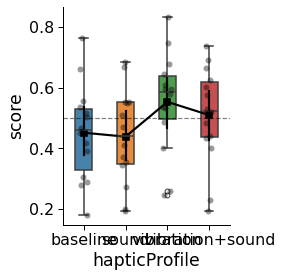

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [12]:
df_agg = df.groupby(['hapticProfile','id']).mean().reset_index()

y = 'answerID'
title = 'answerID'
ylabel = 'score'

# y = 'AccuracyCm'
# title = 'AccuracyCm'

# y = 'fix_delay'

print(df.groupby('hapticProfile')[y].agg(['mean','std']))

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # Plot the orbital period with horizontal boxes
    # sns.boxplot(x=x, y=y, behavior=behavior, whis=[0, 100], width=.3, order= ['intention','involuntary','augmented'], palette=palette, linewidth=1)

    # Add in points to show each observation
    # sns.stripplot(x=x, y=y, behavior=behavior, size=6, palette=palette, linewidth=1, dodge='auto', legend=None)

    # show boxplots
    ax = sns.boxplot(data = df_agg, x = 'hapticProfile', y = y, order= ['baseline','sound','vibration','vibration+sound'], width=.4, hue='hapticProfile', linewidth=1.5)
    for patch in ax.patches: # adapt alpha
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .9))

    # show line connecting means
    ax =  sns.pointplot(data = df_agg, x = 'hapticProfile', y = y, markers="s" ,color = 'black', order= ['baseline','sound','vibration','vibration+sound'])
        
    #  show lines connecting pid means observations    
    # ax = sns.lineplot(data = df_agg, x = 'hapticProfile', y = y, hue = id, palette = sns.color_palette(['black'],8),legend = False,alpha=0.4)
    
#     ax = sns.scatterplot(data = df_agg, x = 'hapticProfile', y = y, s=50, legend= True, marker="s",color = 'black',edgecolor = 'black',alpha=0.4)
    ax = sns.stripplot(data=df_agg, x='hapticProfile', y=y, order=['baseline', 'sound', 'vibration', 'vibration+sound'], jitter=True, size=6, color='black', edgecolor='black', alpha=0.4)
        
    # ax.invert_yaxis()
    # add_stat_annotation(ax, behavior=behavior_means, x=x, y=y, box_pairs=[("baseline", "ems_random"), ("baseline", "ems_bci"), ('ems_random', 'ems_bci')], test='t-test_paired', text_format='star', loc='outside', verbose=2)

    handles, labels = ax.get_legend_handles_labels()  
    
    #plt.legend(handles[3:6],labels[3:6],frameon=True,loc = 'upper left',labelspacing =0.3)

    # add a y line at 0.5 and alpha .5
    ax.axhline(0.5, color='black', alpha=0.5, linestyle='--')

    # set ylimit
    # ax.set_ylim(-450,150)
    
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    ax.set_ylabel(ylabel)
    # ax.set_xlabel(xlabel)
    
    plt.show()

    fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

### Statistics hapticProfile x answerID

In [13]:
import pymer4 as pymer4
from pymer4.models import Lmer

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# Activate the automatic conversion of pandas DataFrames to R data frames
pandas2ri.activate()

full_model = Lmer(y + " ~ hapticProfile + (1|id)", data = df_agg)
# display(full_model.fit(REML = False))
full_model.fit(REML = False)

null_model = Lmer(y + " ~ (1|id)", data = df_agg)
# display(null_model.fit(REML = False))
null_model.fit(REML = False)

lrt_result = pymer4.stats.lrt([null_model, full_model])
display(lrt_result)

# Perform posthoc test using emmeans
emmeans = importr('emmeans')
base = importr('base')

# Convert the fitted model to an R object
full_model_r = full_model.model_obj

# Perform pairwise comparisons
emmeans_result = emmeans.emmeans(full_model_r, 'hapticProfile')
pairwise_comparisons = emmeans.contrast(emmeans_result, 'pairwise')
print(base.summary(pairwise_comparisons))

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~hapticProfile+(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 56	 Groups: {'id': 14.0}

Log-likelihood: 34.780 	 AIC: -57.559

Random effects:

                 Name    Var    Std
id        (Intercept)  0.013  0.113
Residual               0.011  0.105

No random effect correlations specified

Fixed effects:

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 56	 Groups: {'id': 14.0}

Log-likelihood: 29.977 	 AIC: -53.953

Random effects:

                 Name    Var    Std
id        (Intercept)  0.012  0.110
Residual               0.014  0.117

No random effect correlations specified

Fixed effects:



,model,npar,AIC,BIC,log-likelihood,deviance,Chisq,Df,P-val,Sig
0,answerID~(1|id),3,-53.953078,-47.877023,29.976539,-59.953078,,,,
1,answerID~hapticProfile+(1|id),6,-57.559088,-45.406978,34.779544,-69.559088,9.60601,3.0,0.02223,*


 contrast                      estimate     SE   df t.ratio p.value
 baseline - sound                0.0131 0.0411 45.2   0.319  0.9886
 baseline - vibration           -0.1013 0.0411 45.2  -2.467  0.0790
 baseline - (vibration+sound)   -0.0579 0.0411 45.2  -1.410  0.4999
 sound - vibration              -0.1144 0.0411 45.2  -2.786  0.0376
 sound - (vibration+sound)      -0.0710 0.0411 45.2  -1.729  0.3212
 vibration - (vibration+sound)   0.0434 0.0411 45.2   1.057  0.7168

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 4 estimates 



## Change in answerID over time

### Plot correlation answerID x Trial Number

In [14]:
import scipy.stats as stats
def get_correlation(df):
    correlation = df['answerID'].corr(df['Number'])
    p_value = stats.pearsonr(df['answerID'], df['Number'])[1]
    return pd.Series({'correlation': correlation, 'p_value': p_value})

import statsmodels.api as sm
def get_ols_stats(df):
    X = sm.add_constant(df['Number'])  # Add a constant term for the intercept
    y = df['answerID']
    model = sm.OLS(y, X).fit()
    beta = model.params['Number']
    p_value = model.pvalues['Number']
    return pd.Series({'beta': beta, 'p_value': p_value})

df_base = df[df['hapticProfile'] == 'baseline']
df_sound = df[df['hapticProfile'] == 'sound']
df_vibration = df[df['hapticProfile'] == 'vibration']
df_vibration_sound = df[df['hapticProfile'] == 'vibration+sound']

correlation_df_base = df_base.groupby('id').apply(get_correlation).reset_index()
correlation_df_base['hapticProfile'] = 'baseline'
correlation_df_sound = df_sound.groupby('id').apply(get_correlation).reset_index()
correlation_df_sound['hapticProfile'] = 'sound'
correlation_df_vibration = df_vibration.groupby('id').apply(get_correlation).reset_index()
correlation_df_vibration['hapticProfile'] = 'vibration'
correlation_df_vibration_sound = df_vibration_sound.groupby('id').apply(get_correlation).reset_index()
correlation_df_vibration_sound['hapticProfile'] = 'vibration+sound'

correlation_df = pd.concat([correlation_df_base, correlation_df_sound, correlation_df_vibration, correlation_df_vibration_sound])
correlation_df.columns = ['id', 'correlation', 'p', 'hapticProfile']

# print aggregates correaltion_df mean and sd
print(correlation_df.groupby('hapticProfile')['correlation'].agg(['mean','std']))
# print(correlation_df.groupby('hapticProfile')['p'].agg(['mean','std']))

                     mean       std
hapticProfile                      
baseline         0.246430  0.382377
sound            0.184624  0.333876
vibration        0.152194  0.249897
vibration+sound -0.041552  0.359165


                     mean       std
hapticProfile                      
baseline         0.246430  0.382377
sound            0.184624  0.333876
vibration        0.152194  0.249897
vibration+sound -0.041552  0.359165


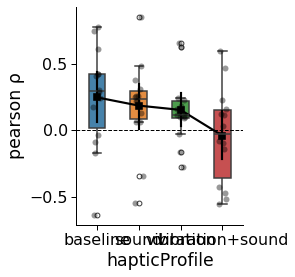

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [15]:
y = 'correlation'
ylabel = 'pearson ρ'
title = 'answerID_x_Number'

print(correlation_df.groupby('hapticProfile')[y].agg(['mean','std']))

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # Plot the orbital period with horizontal boxes
    # sns.boxplot(x=x, y=y, behavior=behavior, whis=[0, 100], width=.3, order= ['intention','involuntary','augmented'], palette=palette, linewidth=1)

    # Add in points to show each observation
    # sns.stripplot(x=x, y=y, behavior=behavior, size=6, palette=palette, linewidth=1, dodge='auto', legend=None)

    # show boxplots
    ax = sns.boxplot(data = correlation_df, x = 'hapticProfile', y = y, order= ['baseline','sound','vibration','vibration+sound'], width=.4, hue='hapticProfile', linewidth=1.5)
    for patch in ax.patches: # adapt alpha
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .9))

    # show line connecting means
    ax = sns.pointplot(data=correlation_df, x='hapticProfile', y=y, markers="s", color='black', order=['baseline', 'sound', 'vibration', 'vibration+sound'])
        
    #  show lines connecting pid means observations    
    # ax = sns.lineplot(data = df_agg, x = 'hapticProfile', y = y, hue = id, palette = sns.color_palette(['black'],8),legend = False,alpha=0.4)
    
    ax = sns.stripplot(data=correlation_df, x='hapticProfile', y=y, order=['baseline', 'sound', 'vibration', 'vibration+sound'], jitter=True, size=6, color='black', edgecolor='black', alpha=0.4)
        
    # ax.invert_yaxis()
    # add_stat_annotation(ax, behavior=behavior_means, x=x, y=y, box_pairs=[("baseline", "ems_random"), ("baseline", "ems_bci"), ('ems_random', 'ems_bci')], test='t-test_paired', text_format='star', loc='outside', verbose=2)

    handles, labels = ax.get_legend_handles_labels()  
    
    #plt.legend(handles[3:6],labels[3:6],frameon=True,loc = 'upper left',labelspacing =0.3)

    # draw a line at y = 0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)


    # set ylimit
    # ax.set_ylim(-450,150)
    
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    ax.set_ylabel(ylabel)
    # ax.set_xlabel(xlabel)
    
    plt.show()

    fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

### Statistics answerID x Trial Number

In [17]:
# full_model = Lmer('correlation' + ' ~ hapticProfile + (1|id)', data = correlation_df)
# display(full_model.fit(REML = False))

# print counts of hapticProfile
print(correlation_df['hapticProfile'].value_counts())

# test if factor levels in hapticProfile are different from 0
import scipy.stats as stats
for hapticProfile in correlation_df['hapticProfile'].unique():
    print(hapticProfile)
    print(stats.ttest_1samp(correlation_df[correlation_df['hapticProfile'] == hapticProfile]['correlation'], 0))

# Model with random intercept and random slopes for Number, hapticProfile, and their interaction
# full_model = Lmer('answerID ~ Number*hapticProfile + (1 + Number + hapticProfile + Number:hapticProfile|id)', data = df)
# display(full_model.fit(REML = False))

hapticProfile
baseline           14
sound              14
vibration          14
vibration+sound    14
Name: count, dtype: int64
baseline
Ttest_1sampResult(statistic=2.4113777613657894, pvalue=0.03140860824734869)
sound
Ttest_1sampResult(statistic=2.0690280824121694, pvalue=0.05903334050154337)
vibration
Ttest_1sampResult(statistic=2.278762262976504, pvalue=0.04021103073731168)
vibration+sound
Ttest_1sampResult(statistic=-0.43287826369194976, pvalue=0.6721983047505941)
